# Sampling at scale: Cluster-GCN

Tier B · full real PPI data. Three live TODOs; complete model/trainer inline. Default run is a two-epoch smoke demonstration. Full Table10 recipe is separately gated. Creating or executing this notebook does not establish learner mastery.

In [ ]:
# @colab-bootstrap · model, sampler, loader and trainer are fully inline below.
import sys, subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','torch==2.8.0','numpy==2.2.6','scipy==1.15.3','scikit-learn==1.7.1','pymetis==2025.2.2'])
import importlib.metadata as metadata
print({n:metadata.version(n) for n in ['torch','numpy','scipy','scikit-learn','pymetis']})


## 0 · Retrieve before reading

**Your win:** build a graph mini-batch that restores every edge between its selected partitions, and explain the memory–information trade-off from your own measurements.

Close the previous lesson. Write answers before opening the explanations: (1) In GraphSAGE, why can a small set of target nodes still require many intermediate nodes? (2) What does an induced subgraph retain? (3) Why must an inductive training graph exclude held-out nodes even if their labels are masked?

Write your three cold-retrieval answers before continuing.

[Lesson 88](https://avistian.github.io/relational/lessons/0088-graph-classification.html) asked which structures an aggregation can distinguish. Expressive aggregation is useful only if we can afford to train it. [Lesson 83](https://avistian.github.io/relational/lessons/0083-graphsage.html) controlled cost by sampling neighbors. Here we change **which nodes share a training step**. This matters for the mission: a relational entity graph may contain millions of rows, and a training method must respect both memory and information-access boundaries.

**Primary reading:** Chiang et al., [Cluster-GCN, KDD 2019, §§3.1–3.3 and Algorithm 1](https://arxiv.org/html/1905.07953v2#S3). Read §4.3 and Table 10 for our named reproduction target. The [2019 release](https://github.com/google-research/google-research/tree/89c16e403d42015c3133634788ed0b7965f56395/cluster_gcn) supplies concrete settings that the algorithm alone does not.

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 089</p><p><strong>Build on what you know.</strong> <a href="https://avistian.github.io/relational/lessons/0083-graphsage.html">Lesson 83</a> bounded neighborhood expansion by sampling at each hop. <a href="https://avistian.github.io/relational/lessons/0088-graph-classification.html">Lesson 88</a> made graph membership explicit. Cluster-GCN instead reuses a chosen induced node set at every depth, changing both cost and the approximation.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0090-gnn-checkpoint.html">Lesson 90</a> asks you to defend the actual experiment. Carry the sampler, normalization and first-layer cache into that defense; the model name alone omits all three.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>



## A batch changes which messages exist

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">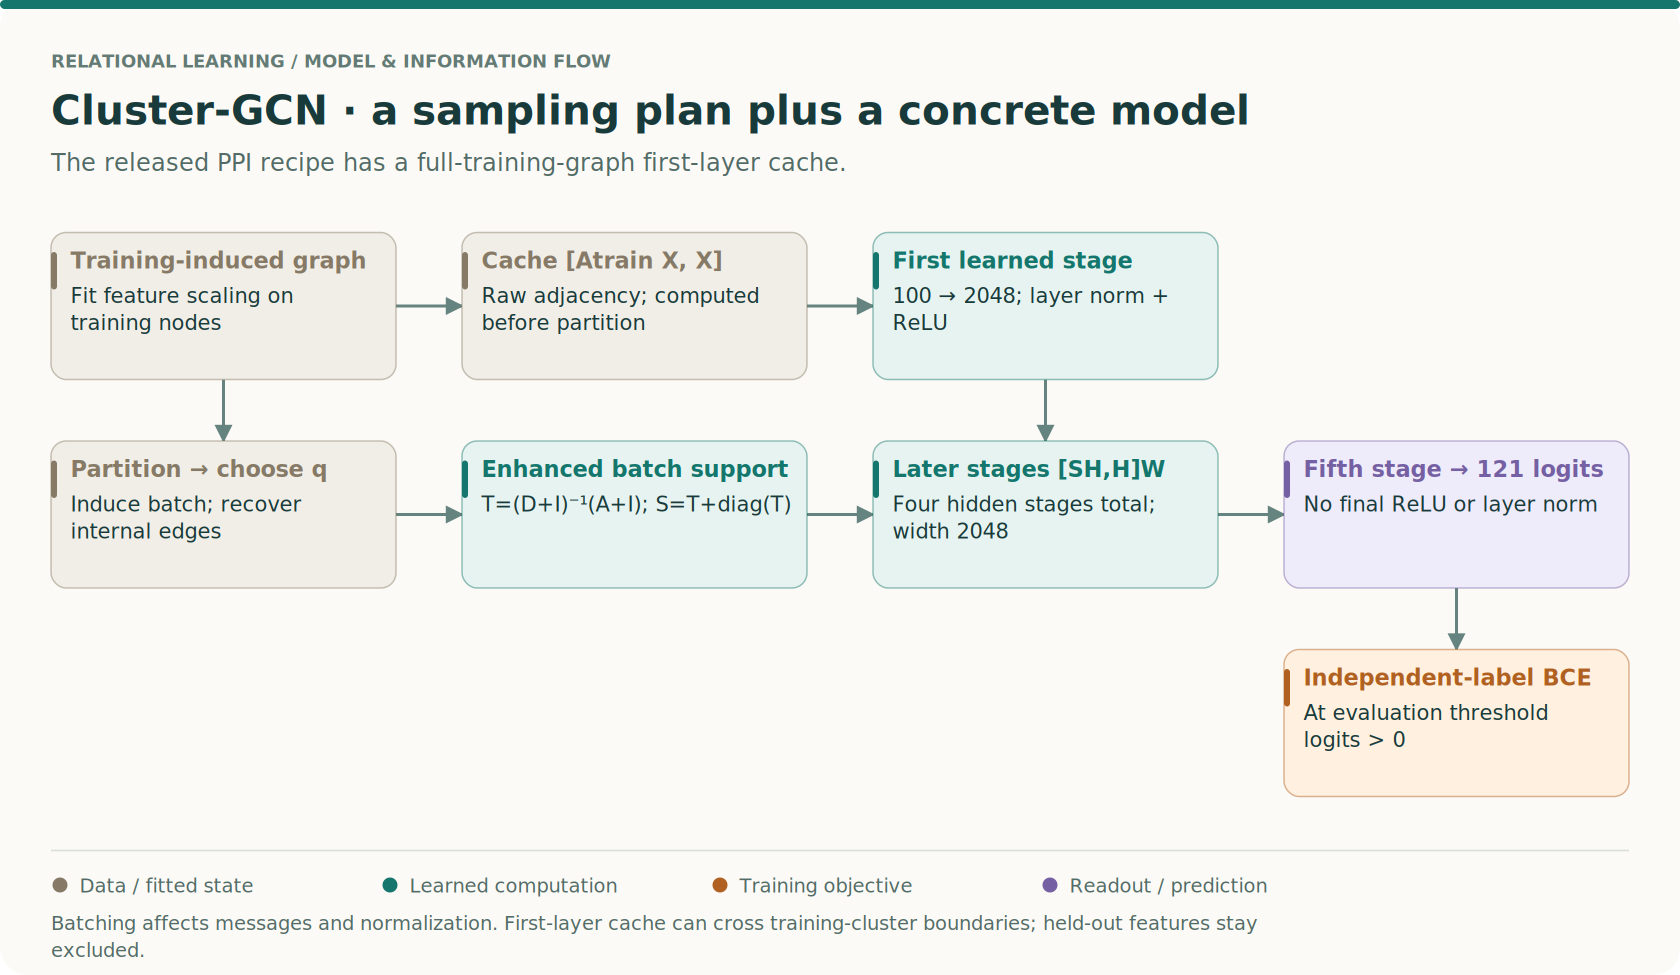</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Read the sampler and the released model separately

Read [Cluster-GCN §§3.1–3.3 and Algorithm 1](https://arxiv.org/html/1905.07953v2#S3), then the Table 10 PPI recipe linked below. Partition-based training is a sampling strategy. The released deep model additionally chooses concatenated self paths, diagonal enhancement and a cached first input. Reproducing a score requires both the sampler and that computation.

### Build a two-cluster thought experiment

1. **Partition eligible training nodes.** Put A,B in one cluster and C,D in another. An edge B—C crosses the partition. Selecting only the first cluster removes that edge from later batch propagation, even though it exists in the full training graph.
2. **Combine clusters before inducing edges.** If both groups are selected, build adjacency from the original eligible graph on their union. Merely concatenating two separately sliced cluster adjacencies would still omit B—C, defeating multi-cluster batching.
3. **Recompute the declared support.** With raw degree d, adding self gives row-normalized weight 1/(d+1). Diagonal enhancement adds another copy of the self coefficient. For a node with two neighbors and λ=1, coefficients are [1/3,2/3,1/3], whose sum is 4/3, not one.
4. **Expose the operator change.** With neighbor/self/neighbor values [1,2,4], the result is 3. Remove the last neighbor through batching and coefficients become [1/2,1], giving 2.5. Missing a neighbor changes both the available sum and its normalization.
5. **Keep the first-layer exception visible.** This PPI release precomputes [A_train X,X] before partitioning. Thus its first input can carry a message across training-cluster boundaries even when later hidden layers cannot. Replacing this cache with a per-batch GCN layer changes the recipe.
6. **Separate cost evidence from accuracy evidence.** A full-width update can verify dimensions, gradients and some memory needs. It cannot establish the final score of a 400-epoch training run. Changing q also changes updates per epoch, so compare optimization budgets explicitly.

<details><summary>Predict: choose every cluster—does this automatically recover the same training trajectory?</summary><p>No. The eligible adjacency can become the full graph, but batch size and the number of optimizer updates per epoch change. Equal forward support is not equal optimization history. Match the intended training procedure before claiming equivalence.</p></details>

**Your intermediate artifact:** draw the crossing edge, compute the two support rows, and mark where the cached first input still uses it. The full named target remains NOT_RUN in the saved evidence; the runnable recipe and smaller teaching experiments are separate achievements.

<!-- depth-walkthrough:end -->



## 1 · Why a mini-batch can grow outside its targets

> **In plain terms.** To update one node, a deep GNN needs intermediate representations of other nodes. A batch of labels is not the same as a batch of computation.

A **full-batch** step computes representations for the whole eligible graph before one parameter update. If there are N nodes, L hidden stages and F coordinates per stage, those dense states alone occupy roughly N×L×F numbers. A float32 number needs four bytes. Gradients, parameters, optimizer state, sparse indices and temporary operations add memory beyond this estimate.

**Worked example.** One million nodes × four stages × 128 coordinates × four bytes is 2.048 billion bytes (about 1.91 GiB) for one copy of those states. This is an accounting example, not a peak-memory measurement.

**Neighbor sampling** takes a fixed number of neighbors per hop. With 256 target nodes and fanouts 10 then 10, there can be 256 + 2,560 + 25,600 = 28,416 node occurrences before deduplication. The same real node may occur repeatedly. Sampling, deduplication and overlap change actual cost; the product explains the pressure as depth grows.

**Cluster sampling** instead chooses a fixed set of nodes and reuses those nodes at every layer. More layers add states and operations, but do not recursively expand the node set. The graph and input features may still occupy host memory. Cluster-GCN is not automatically an out-of-core database engine. See [paper §3.1 and Table 1](https://arxiv.org/html/1905.07953v2#S3.SS1).



## 2 · Partition once; build an induced batch

> **In plain terms.** Put strongly connected nodes together so that a small batch keeps many of the messages those nodes need.

A **partition** splits the eligible nodes into disjoint groups whose union is the whole eligible node set. METIS is a graph partitioner that seeks roughly balanced groups with relatively few edges crossing between groups. Its objective is structural; it does not use the target labels. **Cut edges** connect different groups. An **induced subgraph** on B keeps every original edge with both endpoints in B.

Write A[i,j] for the weight of the edge carrying node j's message to node i. For selected node IDs B, the batch adjacency is **A[B,B]**. Slice both axes in the same node order. A sparse matrix stores only its nonzero entries; there is no reason to allocate a dense million-by-million matrix.

**Worked example.** A six-node path has five edges: 0–1–2–3–4–5. Partition it into C0={0,1}, C1={2,3}, C2={4,5}. One group keeps one edge. Selecting C0 and C1 gives nodes {0,1,2,3} and **three** edges, including the restored edge 1–2. Concatenating two pre-cut block matrices would keep only two edges and implement the wrong algorithm.

Predict before revealing: how many edges belong in the induced union of C0 and C1?

Trace q=1,2,3 selected clusters on the six-node path; retained edge counts are1,3,5.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">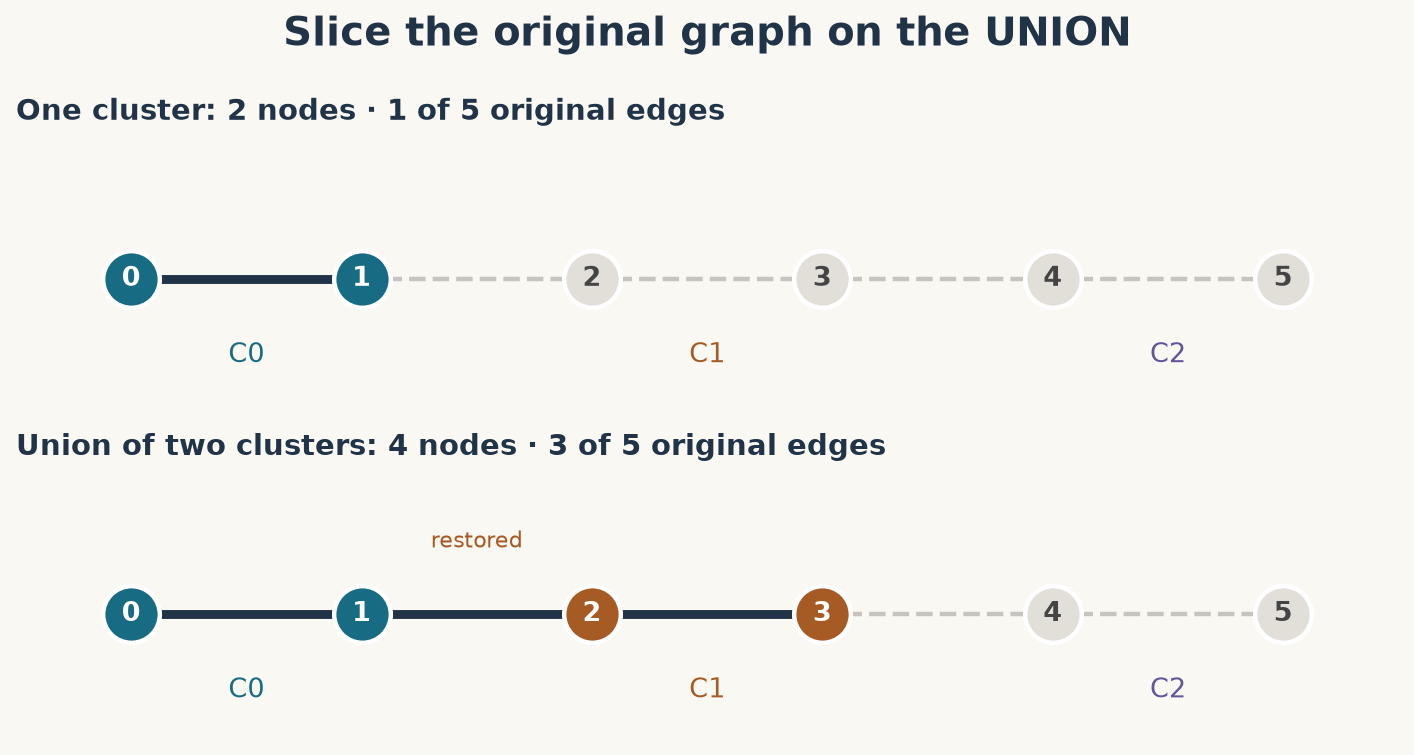</div><figcaption>Synthetic path: the induced union restores edge 1–2; concatenating cut blocks would omit it.</figcaption></figure>

**Indexing checkpoint.** Choose C1 followed by C0. The local-to-global IDs are [2,3,0,1]. Global edge 1–2 becomes local edge 3–0. A correct neighbor sum paired with the wrong feature order is still a wrong model. Your first notebook TODO returns both the IDs and the induced adjacency.



## 3 · Why choose several clusters together?

> **In plain terms.** Clustering saves messages within a group. Mixing groups brings some boundary messages back and changes the labels represented in each update.

One fixed cluster per step can omit the same boundary edges repeatedly. Structurally similar nodes can also have similar labels, so different clusters can give very different gradients. A **gradient** is the change in loss with respect to each trainable parameter. It is the direction used by the optimizer to update weights.

Cluster-GCN's multiple-partition variant shuffles a larger collection of small clusters, then combines q clusters into each induced batch. It uses the original adjacency to restore edges between the chosen groups. q is a number of clusters, not a guaranteed node count; clusters are only approximately balanced. See [paper §3.2, Figure 3 and Algorithm 1](https://arxiv.org/html/1905.07953v2#S3.SS2).

**Worked probability.** Uniformly sample q of p clusters without replacement. Given that one endpoint's cluster is selected, a different endpoint's cluster is selected with probability **(q−1)/(p−1)**. With p=50 and q=5, that is 4/49, about 8.16%. This is a conditional inclusion probability for a crossing edge in a sampled batch, not the fraction of all edges retained. Within-cluster edges are always present whenever their group is selected.

**Missing messages change the function.** Normalization, nonlinear activations and several layers mean the mini-batch gradient need not be an unbiased estimate of the full-graph gradient. More mixing can help, but it does not guarantee better accuracy. Increasing q also increases memory and reduces updates per data pass.

**Limit case.** Choose every cluster: the induced adjacency becomes the full eligible adjacency. With a single full batch, you also get one update per epoch. That changes optimization even when the per-node forward operator is the same.



## 4 · Model architecture: the released deep PPI model

> **In plain terms.** Cluster-GCN chooses the training subgraph. The release also makes specific choices about the GNN that runs inside it. Reproducing its score requires both.

**PPI** is a protein–protein interaction dataset. Nodes have 50 input features and may carry several of 121 labels simultaneously. The original split has 44,906 training, 6,514 validation and 5,524 test nodes. We standardize each input coordinate using its training-node mean and standard deviation; held-out nodes never fit those statistics. The model predicts a vector of 121 **logits**, real-valued scores before a sigmoid conversion to probabilities.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">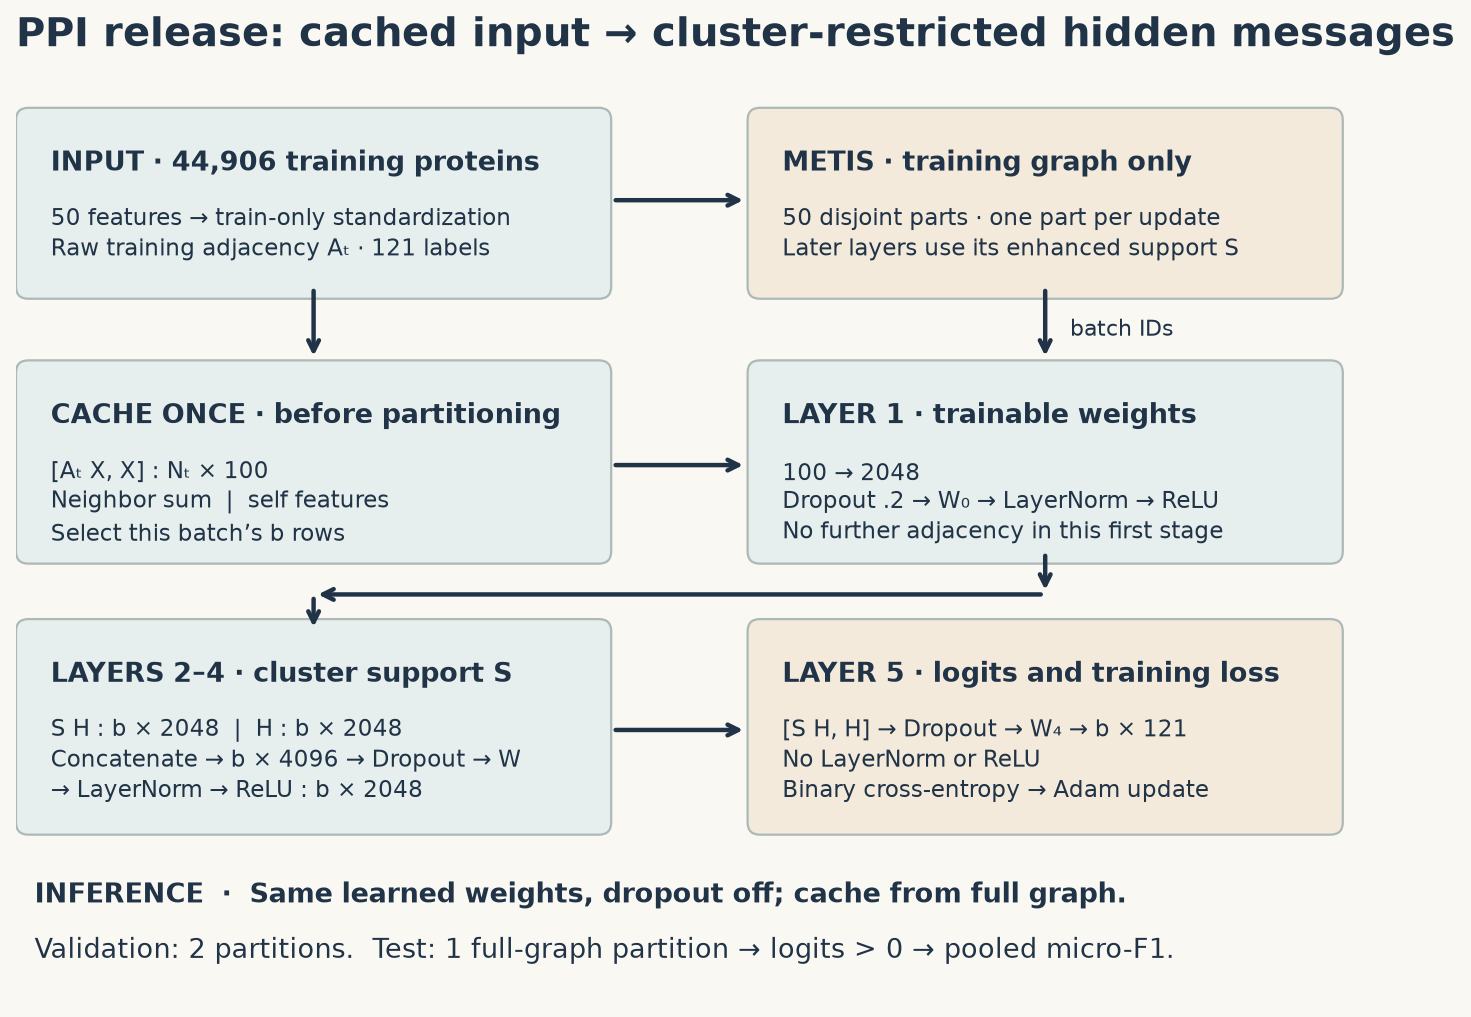</div><figcaption>Complete 2019 PPI release recipe: raw first-layer cache, four hidden stages, output logits and distinct evaluation contexts.</figcaption></figure>

### First stage: a release detail worth noticing

The release precomputes **[A_train X, X]**, a concatenation with 100 columns. A_train is the raw training-induced adjacency. This step occurs **before partitioning**, so first-hop input messages can cross training-cluster boundaries. It never includes held-out input features during training. The first trainable layer applies dropout, a learned matrix, layer normalization and ReLU to this cached input.

The raw first-layer cache is not the normalized support described next. Substituting a standard GCN layer here would change the released model. See [`train.py::load_data`](https://github.com/google-research/google-research/blob/89c16e403d42015c3133634788ed0b7965f56395/cluster_gcn/train.py).

### Later stages: strengthen the center, then concatenate

Let A_B be a batch's adjacency. Add self-loops with the identity I. Let D contain the row sums of A_B. First form T=(D+I)⁻¹(A_B+I): every row divides by its sum. Then use **S=T+λ diag(T)**, with λ=1. `diag(T)` keeps only diagonal entries. This **diagonal enhancement** gives extra weight to a node's own representation. S generally has row sums greater than one; it is not a probability transition matrix.

**Worked example.** For path node1, use scalar states h0=1,h1=2,h2=4. With all three available, the row of S is [1/3,2/3,1/3], giving 1/3+4/3+4/3=3. If its batch contains only nodes0 and1, the row becomes [1/2,1], giving .5+2=2.5. The batch has changed both the messages and their normalization.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">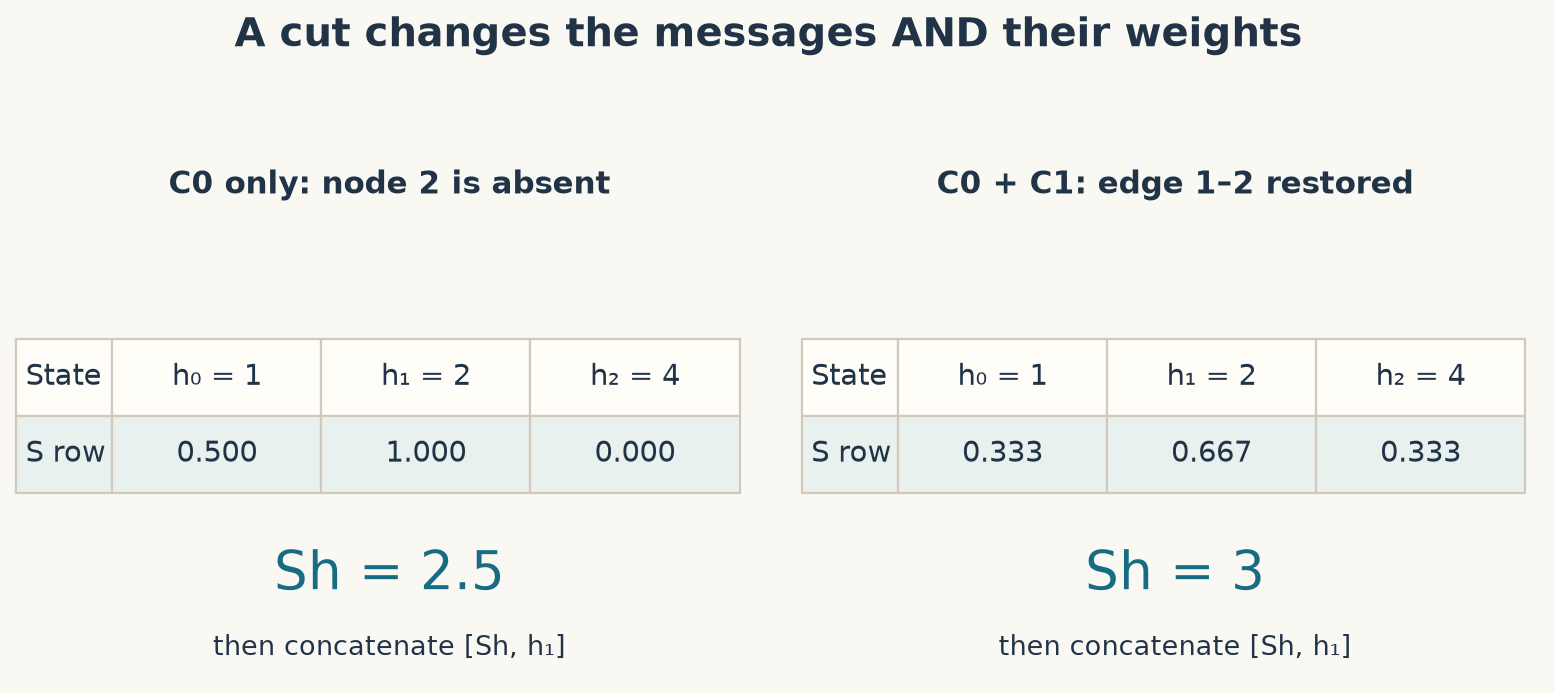</div><figcaption>Synthetic later-layer trace: changing the batch changes node 1’s enhanced message from 2.5 to 3.</figcaption></figure>

At each later hidden layer, compute **[S H, H] W**, apply layer normalization, then ReLU. H has b rows, one per batch node; at hidden width2048, the concatenation has4096 columns. The matrix W mixes those columns into2048 output coordinates. Neighbor and self branches have separate columns of W. **Layer normalization** standardizes coordinates within each node, then learns a scale and offset; it is not a statistic fitted across training and test nodes. **ReLU** clips negative values to zero. **Dropout** randomly removes20% of the concatenated input coordinates during training and rescales those retained.

The five-layer recipe has four hidden stages of width2048. Its fifth layer returns121 logits with no normalization or ReLU. All nodes share the same weights at a given depth; different depths have different weights. Binary cross-entropy penalizes each node-label prediction independently, then averages those losses. At evaluation, a label is predicted present exactly when its logit is greater than zero. **Micro-F1** pools all node-label true positives, false positives and false negatives: 2TP/(2TP+FP+FN).

**Self-loop audit.** The PPI archive already includes some loops. The released loader adds adjacency to its transpose, doubling their raw weight. Its q=1 partition builder replaces nonzero weights with1 before support normalization. The precomputed cache and later supports therefore have different loop conventions. Our paper track preserves this; the teaching experiment uses one binary raw graph in every arm. See the [reproduction contract](https://avistian.github.io/relational/labs/l089-reproduction.md) for the exact sequence.

### Training boundary and inference

Training partitions contain only training nodes. Masking held-out labels alone would not enforce this boundary: their features could still enter messages. At validation, the release precomputes from the full graph and uses two partitions. At final test, it uses the full graph as one partition and scores test nodes only. Evaluation therefore has a different propagation context from training. Test labels never enter the forward pass or choose an epoch.



## 5 · Predict, implement, then measure

**Prediction before evidence.** Write which arm should keep the most edges, which should use the fewest node states, and why neither prediction determines the best test F1.

Open the [student lab](https://avistian.github.io/relational/labs/0089-sampling-at-scale.ipynb), [prepared lab](https://avistian.github.io/relational/labs/html/0089-sampling-at-scale.html), or [Colab notebook](https://colab.research.google.com/github/Avistian/relational/blob/main/labs/0089-sampling-at-scale.ipynb). The [solution](https://avistian.github.io/relational/labs/solutions/0089-sampling-at-scale.ipynb) is for checking after an attempt. The complete model, data loader, partitioner and trainer are visible inline.

1. **TODO · induced batch.** Combine selected partition IDs and recover every original edge between them. CHECK tests an edge that a block-diagonal implementation would lose.
2. **TODO · enhanced support.** Implement the ordered normalization and diagonal adjustment. CHECK includes an isolated node; adding identity makes its support defined.
3. **TODO · concatenated message.** Build neighbor/self branches in the released order. CHECK examines both output values and gradients.

**Experiment held fixed:** all PPI nodes, original split, train-only scaling, a binary raw graph, two layers,width32,dropout.2,Adam.01,ten data passes,three declared seeds. **Varied:** full batch;50 random groups;50 METIS clusters with q1;the same50 clusters with q5. **Measured:** test micro-F1, largest batch, retained adjacency entries, training time, and a dense-hidden-state memory proxy.

> **Scope check.** Equal data passes are not equal updates: the arms make10,500,500 and100 updates respectively. This evaluates the combined batching strategy, not clustering in isolation. The first-hop cache contains all eligible training-neighbor messages in every arm. One dataset and three seeds cannot establish a universal method ranking.

**Author-reference measurements, not your current kernel output.**

| Arm | Test micro-F1, mean ± sample SD | Largest batch | Retained entries | Hidden-state proxy | Train time |
|---|---|---|---|---|---|
| full | 43.54 ± 0.31% | 44,906 | 100.0% | 5.482 MiB | 2.61 s |
| random | 58.28 ± 0.52% | 899 | 3.6% | 0.110 MiB | 2.78 s |
| cluster1 | 58.69 ± 0.54% | 925 | 61.1% | 0.113 MiB | 3.12 s |
| cluster5 | 54.47 ± 0.23% | 4,618 | 63.8% | 0.564 MiB | 2.88 s |

Sample SD describes three initialization/shuffle runs on one fixed split; it is not uncertainty across datasets. Times are CPU author measurements, averaged across seeds.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">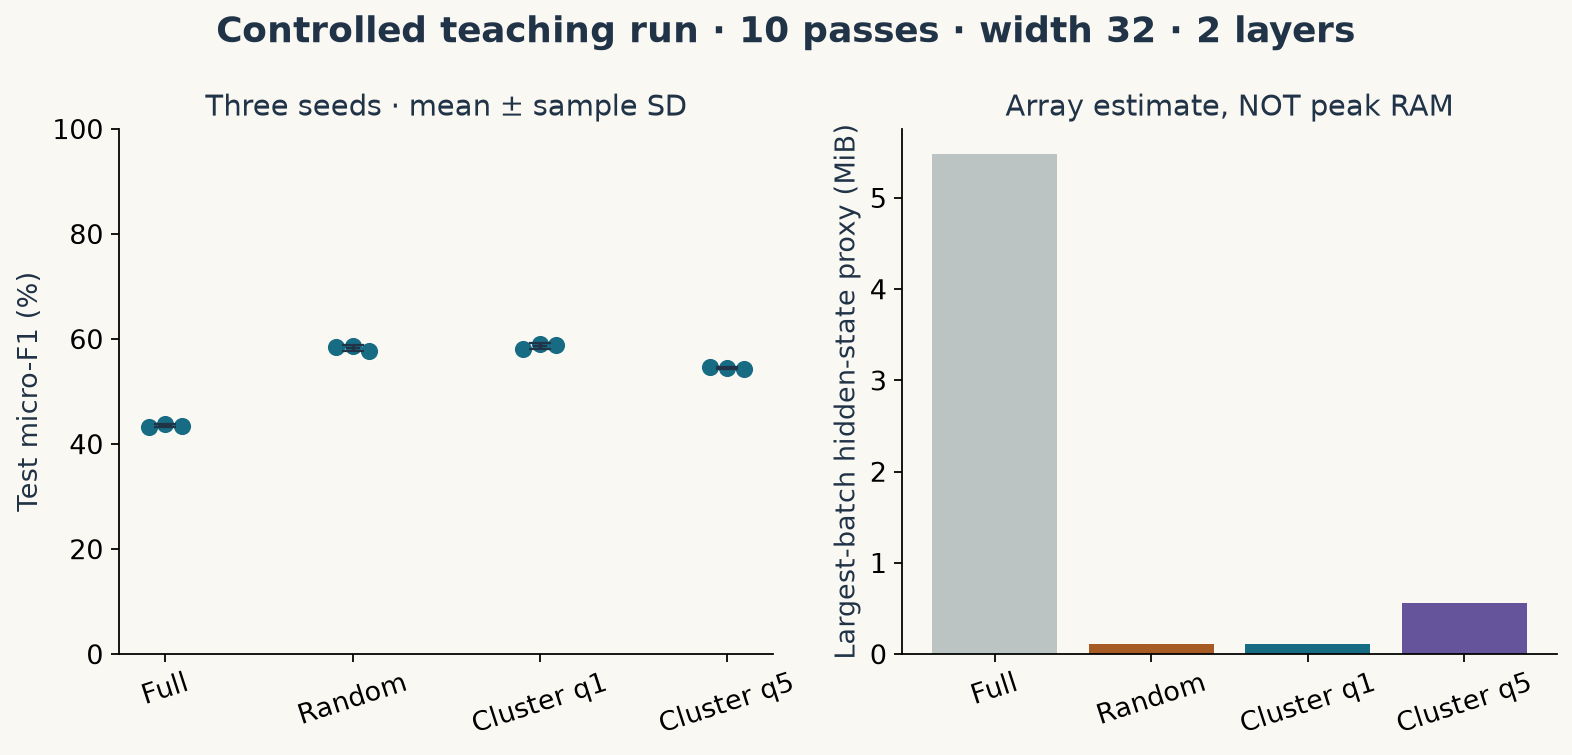</div><figcaption>Fresh PPI teaching experiment: three seeds, ten passes and a hidden-state array estimate; not the paper target or peak-memory measurement.</figcaption></figure>

The memory column counts one float32 hidden-state array per hidden stage at the largest batch. It excludes parameters, gradients, optimizer buffers, sparse matrices, caches and temporaries. It is **not peak RAM or VRAM**. Retention counts directed nonzero adjacency entries, including loops; it is not the conditional probability derived in §3. Training time excludes graph preprocessing and evaluation.

**Interpretation task.** Random grouping and clustering have very different edge retention here. Explain why their F1 values can nevertheless be close: input caching, model width, training duration, optimization and seed variability all matter. Propose an update-matched follow-up before claiming one factor caused the difference.



## 6 · Full reproduction: one named cell, explicit evidence

**Target:** [paper Table10](https://arxiv.org/html/1905.07953v2#S4.SS3), PPI test micro-F1 **99.36%**. The release's `run_ppi.sh` specifies five layers,width2048,50 clusters,q1,400 epochs,dropout.2,diagonal enhancement1 and layer normalization. Table4's width512 belongs to different experiments; copying it would not reproduce this target.

Our full command uses every released training node and all400 epochs. The release keeps final-epoch weights: its patience1000 is longer than the run. We do not substitute a best-validation checkpoint or select from test scores. NumPy shuffle seed1 is retained; fresh PyTorch initialization seed1 is declared. Historical initialization and partition identity cannot be recovered from the paper alone.

```bash
python labs/_run_l089.py --preset paper --device cuda \
  --seed 1 --output /tmp/l089-full-fresh
python labs/_audit_l089.py --run /tmp/l089-full-fresh
```

See the [environment pins](https://avistian.github.io/relational/labs/requirements-l089-runtime.txt), [source hashes](https://avistian.github.io/relational/labs/_sources_l089.json), [complete protocol audit](https://avistian.github.io/relational/labs/l089-reproduction.md), and [execution ledger](https://avistian.github.io/relational/labs/_paper_l089_results.json). The notebook has a gated full-run cell; the repository includes a persistent Modal operator. A smoke or closer preset is a separately labeled experiment.

**Full paper run: NOT_RUN.** The full GPU run was blocked: Modal rejected A10G and T4 execution with a payment-method requirement. No GPU training launched. A local full-width update took 2.02s; the released run requires 20,000 updates plus evaluation, beyond this authoring run. Historical result parity: **INCOMPARABLE**. Full-model one-update preflight and the completed teaching comparison are separate evidence.

**Evidence boundary.** PyTorch/PyMetis versus historical TensorFlow/METIS, missing original partitions and missing initial weights make historical numerical parity **INCOMPARABLE**. The source's normalization functions, an independent dense forward calculation, gradient routing, optimizer arithmetic and held-out interventions are checked locally. Those checks support implementation correctness, not a completed paper result. Reddit, Amazon2M and the original timing/memory benchmark remain **NOT_RUN**.



## 7 · EXIT: justify the batch you trained

Submit `l089-exit.json`, your three TODO implementations, a table from your own four-arm experiment, and the explanation below. The EXIT writer refuses to mark completion without all12 run records and substantive explanations. Author-reference results are not your live notebook output.

- Trace edge1–2 and the local IDs when C1 and C0 are combined.
- Explain why lost edges can bias the gradient even with uniform cluster selection.
- Distinguish measured F1, estimated hidden-state bytes, and unmeasured peak memory.
- Give one remaining mismatch between the runnable full recipe and historical result parity.

Explain the memory and gradient trade-off, including the cache and unequal update counts.

Tomorrow, derive the conditional boundary-edge inclusion probability without opening this page. At the next checkpoint, choose full-batch, neighbor sampling or cluster sampling for a stated graph and memory budget, then defend the information boundary. This connects to the planned Lesson90 checkpoint and later large relational entity graphs.

Ask the teaching agent follow-up questions whenever the normalization, sampling boundary or evidence ledger is unclear. Bring the graph trace or run artifact so feedback can target the actual computation.


## PROVIDED / TODO / CHECK · implementation

Read the docstrings as contracts. Your three functions are used in live sampling and propagation. No hidden solution import replaces them. `train` uses `induced_batch` when q>1; the immediate smoke run uses q5 to exercise that path.

In [ ]:
import hashlib
import json
import math
import time
import urllib.request
import zipfile
from pathlib import Path
import numpy as np
import scipy.sparse as sp
import pymetis
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler
DATA_URL = 'https://snap.stanford.edu/graphsage/ppi.zip'
DATA_SHA = '53aeb76e54fd41b645e7edb48b62929240b89839495396b048086fd212503fbd'
torch.set_num_threads(1)

PROVIDED · `load_ppi`

Full GraphSAGE PPI archive; train-only scaling, legacy JSON endpoint mapping.

In [ ]:
def load_ppi(root='l089-data'):
    """Full GraphSAGE PPI archive; train-only scaling, legacy JSON endpoint mapping."""
    root = Path(root); root.mkdir(parents=True, exist_ok=True)
    archive = root / 'ppi.zip'
    if not archive.exists():
        urllib.request.urlretrieve(DATA_URL, archive)
    if hashlib.sha256(archive.read_bytes()).hexdigest() != DATA_SHA:
        raise ValueError('PPI archive hash mismatch')
    with zipfile.ZipFile(archive) as z:
        def member(suffix):
            names = [n for n in z.namelist() if n.endswith(suffix)]
            assert len(names) == 1
            return z.open(names[0])
        graph = json.load(member('-G.json'))
        ids = {int(k): int(v) for k,v in json.load(member('-id_map.json')).items()}
        labels = json.load(member('-class_map.json'))
        x = np.load(member('-feats.npy'), allow_pickle=False).astype(np.float32)
    n = len(ids)
    masks = {k: np.zeros(n, dtype=bool) for k in ['train','valid','test']}
    y = np.zeros((n,121),dtype=np.float32)
    for node in graph['nodes']:
        if int(node['id']) not in ids: continue
        i = ids[int(node['id'])]
        masks['valid'][i] = node['val']; masks['test'][i] = node['test']
        masks['train'][i] = not(node['val'] or node['test'])
        y[i] = labels[str(node['id'])]
    rows,cols = [],[]
    # networkx 1.11 node-link format stores indices into the nodes list.
    for edge in graph['links']:
        u = int(graph['nodes'][edge['source']]['id'])
        v = int(graph['nodes'][edge['target']]['id'])
        if u in ids and v in ids:
            rows.append(ids[u]); cols.append(ids[v])
    # NetworkX Graph collapses duplicates; preserve doubled diagonal from A + A.T.
    a = sp.csr_matrix((np.ones(len(rows)),(rows,cols)),shape=(n,n),dtype=np.float32)
    a.data[:] = 1
    a = (a + a.T).tocsr()
    scaler = StandardScaler().fit(x[masks['train']])
    x = scaler.transform(x).astype(np.float32)
    assert n == 56944 and x.shape == (n,50) and y.shape == (n,121)
    assert np.all(sum(m.astype(int) for m in masks.values()) == 1)
    return {'a':a,'x':x,'y':y,'masks':masks,'scaler_mean':scaler.mean_}

TODO · `induced_batch`

TODO: concatenate selected disjoint partitions; slice ORIGINAL A on both axes.

In [ ]:
def induced_batch(a, parts, chosen):
    'TODO: concatenate selected disjoint partitions; slice ORIGINAL A on both axes.\n\nReturn (global node IDs in partition order, CSR adjacency in that local order).\nPreserve edges between selected partitions. Do not concatenate block diagonals.'
    raise NotImplementedError("TODO: induced_batch")

In [ ]:
a=sp.csr_matrix(np.array([[0,1,0,0],[1,0,1,0],[0,1,0,1],[0,0,1,0]],dtype=np.float32))
parts=[np.array([0,1]),np.array([2,3])]
ids,b=induced_batch(a,parts,[1,0])
np.testing.assert_array_equal(ids,[2,3,0,1]);assert b.nnz==6, 'Restore the crossing edge, in both directions'
assert b[3,0]==1, 'Global edge1–2 must become local edge3–0'
print('CHECK: induced edges and ID order pass')

TODO · `enhanced_support`

TODO: add I, row-normalize, then add lambda times the resulting diagonal.

In [ ]:
def enhanced_support(a, diag_lambda=1.0):
    "TODO: add I, row-normalize, then add lambda times the resulting diagonal.\n\nS = (D+I)^(-1)(A+I) + lambda*diag((D+I)^(-1)(A+I)).\nThe final row sum need not be one. diag_lambda=-1 is the release's plain D^-1 A."
    raise NotImplementedError("TODO: enhanced_support")

In [ ]:
a=sp.csr_matrix(np.array([[0,1,0],[1,0,1],[0,1,0]],dtype=np.float32))
s=enhanced_support(a).toarray()
np.testing.assert_allclose(s[1],[1/3,2/3,1/3],rtol=1e-6)
np.testing.assert_allclose(enhanced_support(sp.csr_matrix((1,1))).toarray(),[[2.]])
print('CHECK: enhancement order and isolated node pass')

PROVIDED · `partition`

Partition eligible nodes only. PyMetis 2025.2.2 is a declared runtime deviation.

In [ ]:
def partition(a, num_parts=50, method='metis', seed=1):
    """Partition eligible nodes only. PyMetis 2025.2.2 is a declared runtime deviation."""
    n = a.shape[0]
    if not 1 <= num_parts <= n: raise ValueError('Invalid partition count')
    if num_parts == 1: return [np.arange(n,dtype=np.int64)]
    if method == 'random':
        return [p.astype(np.int64) for p in np.array_split(np.random.RandomState(seed).permutation(n),num_parts)]
    clean = a.copy(); clean.setdiag(0); clean.eliminate_zeros(); clean.sort_indices()
    # Legacy metis.part_graph defaults to multilevel k-way (not recursive bisection).
    _, membership = pymetis.part_graph(num_parts,
        adjacency=[clean.indices[clean.indptr[i]:clean.indptr[i+1]].tolist() for i in range(n)],
        recursive=False, options=pymetis.Options(seed=seed))
    membership = np.asarray(membership)
    parts = [np.flatnonzero(membership == k) for k in range(num_parts)]
    if any(len(p)==0 for p in parts): raise ValueError('Empty partition')
    return parts

PROVIDED · `sparse_tensor`

Sparse COO; rows are receivers, columns senders.

In [ ]:
def sparse_tensor(a, device='cpu'):
    """Sparse COO; rows are receivers, columns senders."""
    a = a.tocoo()
    return torch.sparse_coo_tensor(np.stack([a.row,a.col]),a.data,a.shape,
                                   dtype=torch.float32,device=device).coalesce()

TODO · `concat_message`

TODO: return [S @ H, H], neighbor branch first, with gradients through both.

In [ ]:
def concat_message(h, support):
    'TODO: return [S @ H, H], neighbor branch first, with gradients through both.'
    raise NotImplementedError("TODO: concat_message")

In [ ]:
h=torch.tensor([[1.],[2.],[4.]],requires_grad=True)
s=sparse_tensor(enhanced_support(sp.csr_matrix([[0,1,0],[1,0,1],[0,1,0]])))
y=concat_message(h,s)
torch.testing.assert_close(y[1],torch.tensor([3.,2.]))
y.sum().backward()
torch.testing.assert_close(h.grad,(s.to_dense().sum(0)+1)[:,None])
print('CHECK: neighbor/self order and gradients pass')

PROVIDED · `ClusterGCN`

Release GraphConvolution: concat -> dropout -> W -> per-node LN -> ReLU.

In [ ]:
class ClusterGCN(nn.Module):
    """Release GraphConvolution: concat -> dropout -> W -> per-node LN -> ReLU.

    First input is precomputed [A_train X, X], with raw (not normalized) A.
    The final layer omits layer norm and ReLU. No affine bias; LN has scale/offset.
    """
    def __init__(self, features=50, labels=121, hidden=2048, layers=5, dropout=.2):
        super().__init__()
        if layers < 2: raise ValueError('Use at least two layers')
        dims = [features]+[hidden]*(layers-1)+[labels]
        self.weights = nn.ParameterList([nn.Parameter(torch.empty(2*dims[i],dims[i+1])) for i in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden,eps=1e-9) for _ in range(layers-1)])
        self.dropout = dropout
        for w in self.weights: nn.init.xavier_uniform_(w)
    def forward(self, precomputed, support):
        h = precomputed
        for i,w in enumerate(self.weights):
            joined = h if i == 0 else concat_message(h,support)
            h = F.dropout(joined,p=self.dropout,training=self.training) @ w
            if i < len(self.weights)-1: h = F.relu(self.norms[i](h))
        return h

PROVIDED · `ReleaseAdam`

TF1 Adam epsilon placement: lr_t*m / (sqrt(v)+epsilon), epsilon=1e-8.

In [ ]:
class ReleaseAdam:
    """TF1 Adam epsilon placement: lr_t*m / (sqrt(v)+epsilon), epsilon=1e-8.

    Unlike torch.optim.Adam, epsilon is added before the second-moment bias correction.
    Only dense gradients and zero weight decay are needed by the released PPI recipe.
    """
    def __init__(self, params, lr=.01):
        self.params = list(params); self.lr = lr; self.t = 0
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
    def zero_grad(self):
        for p in self.params: p.grad = None
    @torch.no_grad()
    def step(self):
        self.t += 1
        alpha = self.lr * math.sqrt(1-.999**self.t)/(1-.9**self.t)
        for p,m,v in zip(self.params,self.m,self.v):
            if p.grad is None: continue
            m.mul_(.9).add_(p.grad,alpha=.1)
            v.mul_(.999).addcmul_(p.grad,p.grad,value=.001)
            p.addcdiv_(m,v.sqrt().add_(1e-8),value=-alpha)

PROVIDED · `micro_f1`

Pool binary decisions across nodes AND labels; threshold logits strictly above zero.

In [ ]:
def micro_f1(logits, labels):
    """Pool binary decisions across nodes AND labels; threshold logits strictly above zero."""
    p = np.asarray(logits)>0; y = np.asarray(labels)>.5
    tp = np.count_nonzero(p & y); fp = np.count_nonzero(p & ~y); fn = np.count_nonzero(~p & y)
    return float(2*tp/max(1,2*tp+fp+fn))

PROVIDED · `prepare`

Training graph and first-layer cache never access held-out features/edges/labels.

In [ ]:
def prepare(data, num_parts=50, method='metis', partition_seed=1):
    """Training graph and first-layer cache never access held-out features/edges/labels."""
    train_ids = np.flatnonzero(data['masks']['train'])
    a = data['a'][train_ids][:,train_ids].tocsr(); x = data['x'][train_ids]
    t = time.perf_counter()
    parts = partition(a,num_parts,method,partition_seed)
    pre = np.concatenate([a @ x,x],axis=1).astype(np.float32)
    return {'a':a,'pre':pre,'y':data['y'][train_ids],'parts':parts,
            'ids':train_ids,'preprocess_seconds':time.perf_counter()-t}

PROVIDED · `evaluate`

Release inference: precompute on full graph; validation uses 2 parts, test 1.

In [ ]:
@torch.no_grad()
def evaluate(model, data, mask_name, num_parts=1, device='cpu'):
    """Release inference: precompute on full graph; validation uses 2 parts, test 1.

    Stream partitions from host. PPI tissues are disconnected, but a METIS partition
    can still cut a tissue. Validation/test labels never enter the forward pass.
    """
    model.eval()
    a,x = data['a'],data['x']; mask = data['masks'][mask_name]
    pre = np.concatenate([a@x,x],axis=1).astype(np.float32)
    parts = partition(a,num_parts)
    all_ids,all_logits = [],[]
    total_loss = 0.0
    for nodes in parts:
        selected = mask[nodes]
        if not selected.any(): continue
        block = a[nodes][:,nodes].copy(); block.data[:] = 1  # release partition_graph binarizes
        s = sparse_tensor(enhanced_support(block),device)
        logits = model(torch.as_tensor(pre[nodes],device=device),s)
        z = logits[torch.as_tensor(selected,device=device)]
        target = torch.as_tensor(data['y'][nodes[selected]],device=device)
        total_loss += float(F.binary_cross_entropy_with_logits(z,target))*int(selected.sum())
        all_ids.append(nodes[selected]); all_logits.append(z.cpu().numpy())
    ids = np.concatenate(all_ids); logits = np.concatenate(all_logits)
    order = np.argsort(ids); ids,logits = ids[order],logits[order]
    return {'loss':total_loss/len(ids),'micro_f1':micro_f1(logits,data['y'][ids])},ids,logits

PROVIDED · `preset`

Named paper target never silently shrinks. Other presets are different experiments.

In [ ]:
def preset(name):
    """Named paper target never silently shrinks. Other presets are different experiments."""
    configs = {
        'smoke':dict(hidden=32,layers=2,epochs=2,num_parts=50,q=1),
        'closer':dict(hidden=128,layers=3,epochs=30,num_parts=50,q=1),
        'paper':dict(hidden=2048,layers=5,epochs=400,num_parts=50,q=1),
    }
    return dict(configs[name],dropout=.2,lr=.01,partition_method='metis',partition_seed=1)

PROVIDED · `train`

Fresh complete trainer: full training data, shuffled partition pass per epoch.

In [ ]:
def train(data, config, seed=1, device='cpu', output=None, validate_every=1, test=True):
    """Fresh complete trainer: full training data, shuffled partition pass per epoch.

    Fixed final epoch, no best-validation checkpoint (the released recipe disables
    early stopping with patience 1000 > 400). Test runs once after training on CPU.
    Config + source hashes + runtime are persisted by the CLI; no resume is implied.
    """
    torch.manual_seed(seed); rng = np.random.RandomState(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.set_num_threads(1)
    prep = prepare(data,config['num_parts'],config['partition_method'],config['partition_seed'])
    model = ClusterGCN(hidden=config['hidden'],layers=config['layers'],dropout=config['dropout']).to(device)
    opt = ReleaseAdam(model.parameters(),config['lr'])
    parts = prep['parts']; order = np.arange(len(parts)); curves = []
    out = Path(output) if output is not None else None
    if out:
        out.mkdir(parents=True,exist_ok=True)
        np.savez_compressed(out/'partitions.npz',train_ids=prep['ids'],**{f'p{i}':p for i,p in enumerate(parts)})
    # q=1 uses fixed supports, as the release. Keep tensors on CPU until their batch.
    cached = {}
    if config['q']==1:
        for i,p in enumerate(parts):
            block = prep['a'][p][:,p].copy(); block.data[:] = 1
            cached[i] = (p,enhanced_support(block))
    max_nodes,max_nnz,retained = 0,0,[]
    train_seconds = 0.0
    for epoch in range(1,config['epochs']+1):
        if device.startswith('cuda'): torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        start = time.perf_counter(); model.train(); loss_sum = 0; count = 0; edges_seen = 0
        rng.shuffle(order)
        # The q=1 release shuffles idx_parts twice, preserving this otherwise redundant step.
        if config['q']==1: rng.shuffle(order)
        for begin in range(0,len(order),config['q']):
            chosen = order[begin:begin+config['q']]
            if config['q']==1:
                nodes,s = cached[int(chosen[0])]
            else:
                nodes,a = induced_batch(prep['a'],parts,chosen); s = enhanced_support(a)
            support = sparse_tensor(s,device)
            x = torch.as_tensor(prep['pre'][nodes],device=device)
            y = torch.as_tensor(prep['y'][nodes],device=device)
            opt.zero_grad(); logits = model(x,support)
            loss = F.binary_cross_entropy_with_logits(logits,y)
            loss.backward(); opt.step()
            loss_sum += float(loss.detach())*len(nodes); count += len(nodes)
            max_nodes = max(max_nodes,len(nodes)); max_nnz = max(max_nnz,s.nnz)
            edges_seen += prep['a'][nodes][:,nodes].nnz
        if device.startswith('cuda'): torch.cuda.synchronize()
        elapsed = time.perf_counter()-start; train_seconds += elapsed
        row = {'epoch':epoch,'train_loss':loss_sum/count,'train_seconds':elapsed,
               'edge_fraction':edges_seen/max(1,prep['a'].nnz)}
        if device.startswith('cuda'): row['cuda_peak_allocated_bytes'] = torch.cuda.max_memory_allocated()
        if epoch % validate_every == 0 or epoch == config['epochs']:
            metrics,_,_ = evaluate(model,data,'valid',2,device)
            row.update({'valid_'+k:v for k,v in metrics.items()})
        curves.append(row); retained.append(row['edge_fraction'])
        if out:
            (out/'progress.json').write_text(json.dumps({'status':'INCOMPLETE','config':config,'seed':seed,'curves':curves},indent=2))
        print(f"epoch={epoch}/{config['epochs']} loss={row['train_loss']:.5f} train_s={elapsed:.2f}"+
              (f" val_F1={row['valid_micro_f1']:.5f}" if 'valid_micro_f1' in row else ''),flush=True)
    result = {'status':'COMPLETE','config':config,'seed':seed,'selection':'final_epoch',
              'train_nodes':len(prep['ids']),'train_directed_nnz':prep['a'].nnz,
              'max_batch_nodes':max_nodes,'max_support_nnz':max_nnz,
              'hidden_state_proxy_bytes':4*max_nodes*config['hidden']*(config['layers']-1),
              'mean_retained_edge_fraction':float(np.mean(retained)),
              'preprocess_seconds':prep['preprocess_seconds'],'training_seconds':train_seconds,'curves':curves}
    if test:
        model.cpu()
        metrics,ids,logits = evaluate(model,data,'test',1,'cpu')
        result['test'] = metrics
        if out:
            np.savez_compressed(out/'test_predictions.npz',ids=ids,logits=logits,labels=data['y'][ids])
            result['prediction_sha256'] = hashlib.sha256((out/'test_predictions.npz').read_bytes()).hexdigest()
    if out:
        torch.save(model.cpu().state_dict(),out/'model.pt')
        (out/'result.json').write_text(json.dumps(result,indent=2)+'\n')
    return result

## RUN · fresh real-data smoke

This loads the full hash-verified archive (about27MB compressed) and runs two width32 epochs. It tests all three TODOs but does not reproduce Table10. Cache uses original release loop weights.

In [ ]:
data=load_ppi()
smoke=train(data,dict(preset('smoke'),q=5),seed=1,device='cpu')
print('Live smoke test micro-F1:',smoke['test']['micro_f1'])

## RUN · your controlled four-arm experiment

First write predictions about edge retention and memory. Set `RUN_TEACHING=True` for all12 runs. The binary raw graph is held fixed; passes are matched but optimizer updates differ.

In [ ]:
RUN_TEACHING = False
learner_results = []
if RUN_TEACHING:
    controlled = dict(data, a=data['a'].copy())
    controlled['a'].data[:] = 1  # same binary graph in all arms
    for mode,method,p,q in [('full','metis',1,1),('random','random',50,1),('cluster1','metis',50,1),('cluster5','metis',50,5)]:
        for seed in [1,2,3]:
            cfg=dict(preset('smoke'),epochs=10,num_parts=p,q=q,partition_method=method)
            record=train(controlled,cfg,seed,'cpu',output=f'l089-teaching/{mode}-seed{seed}',validate_every=10)
            record['mode']=mode
            learner_results.append(record)
    for mode in ['full','random','cluster1','cluster5']:
        scores=[r['test']['micro_f1'] for r in learner_results if r['mode']==mode]
        print(mode, 'mean', np.mean(scores), 'sample SD', np.std(scores,ddof=1))


## EXIT · runnable evidence and explanation

Complete the three text fields with at least40 characters each. All12 completed run records are required. A smoke result alone does not pass.

In [ ]:
explanations={'boundary_edge_and_gradient':'','memory_and_update_budget':'','historical_reproduction_gap':''}
expected={(m,s) for m in ['full','random','cluster1','cluster5'] for s in [1,2,3]}
coverage={(r['mode'],r['seed']) for r in learner_results if r['status']=='COMPLETE' and r['config']['epochs']==10}
exit_artifact={'complete':coverage==expected and len(learner_results)==12 and all(len(v.strip())>=40 for v in explanations.values()),'results':learner_results,'explanations':explanations,'smoke':smoke['test']}
Path('l089-exit.json').write_text(json.dumps(exit_artifact,indent=2))
print('EXIT complete:',exit_artifact['complete'])

## FULL REPRODUCTION · Table10 PPI

The full recipe is all400 epochs at width2048,5 layers. Choose a durable GPU runtime. Paper performance is cited, not established by running a smoke preset. The notebook preserves results under `l089-paper`; use a fresh directory to avoid overwriting evidence. Original TF1/METIS parity remains INCOMPARABLE.

In [ ]:
RUN_PAPER_REPRO=False
PAPER_PRESET='paper'
if RUN_PAPER_REPRO:
    device='cuda' if torch.cuda.is_available() else 'cpu'
    out=Path('l089-paper')
    if out.exists() and any(out.iterdir()): raise ValueError('Use a fresh output directory')
    full_result=train(data,preset(PAPER_PRESET),seed=1,device=device,output=out)
    print({'preset':PAPER_PRESET,'test':full_result['test'],'historical_parity':'INCOMPARABLE'})